In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE FAIR MODEL COMPARISON + XAI ANALYSIS (v3: 5s Windows + WST)
# ═══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS TESTING:
#   H1: DeepGAT learns electrode connectivity → outperforms on multi-subject
#   H2: Right hemisphere channels contribute more to emotion classification
#   H3: Frontal alpha asymmetry (F3/F4) is a key discriminative feature
#   H4: WST captures multi-scale temporal structure → improves cross-subject
#   H5: Trial-level majority voting boosts accuracy (24 windows/trial)
#
# SCENARIOS (all models trained on IDENTICAL data, same splits):
#   1a. Single DEAP subject — within-subject 5-fold CV (trial-aware)
#   1b. OpenBCI (my brain) — StratifiedGroupKFold by trial
#   2a. 20 DEAP subjects — within-subject stratified 80/20 per subject
#   2b. Cross-subject LOSO — train 19, test 1 (10 folds)
#
# CHANGES IN v3 (inspired by Elrefaiy et al. 2025):
#   - 5s windows (was 2s) → better frequency resolution
#   - 2.5s step / 50% overlap (was 125ms/93% overlap)
#   - +7 WST features per channel (Hjorth, HFD, Skewness, Kurtosis, LogEnergy)
#   - Trial-level majority voting post-hoc
# ═══════════════════════════════════════════════════════════════════════════════

import os, pickle, warnings, glob, math, time, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyeeg as pe
from tqdm import tqdm
from collections import Counter
from scipy import stats as scipy_stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedGroupKFold, StratifiedKFold,
                                     train_test_split)
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from kymatio.numpy import Scattering1D

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = r'C:\Users\PC\Desktop\EEG_GraphAttentionNetwork'
OPENBCI_BASE = os.path.join(PROJECT_ROOT, 'data', 'recordings_clean')
OPENBCI_FEAT = os.path.join(OPENBCI_BASE, 'data_extracted_v3')
OPENBCI_FOLDERS = {
    'calm':     os.path.join(OPENBCI_BASE, 'recordings_calm_cleaned'),
    'happy':    os.path.join(OPENBCI_BASE, 'recordings_happy_cleaned'),
    'sad':      os.path.join(OPENBCI_BASE, 'recordings_sad_cleaned'),
    'stressed': os.path.join(OPENBCI_BASE, 'recordings_stressed_cleaned'),
}
DEAP_DATA = os.path.join(PROJECT_ROOT, 'data', 'DEAP', 'data_preprocessed_python')
DEAP_FEAT = os.path.join(PROJECT_ROOT, 'data', 'DEAP', 'output', 'features')
os.makedirs(DEAP_FEAT, exist_ok=True)

OUT_DIR = os.path.join(OPENBCI_BASE, 'model_comparison_v3')
os.makedirs(OUT_DIR, exist_ok=True)

# ─── Channel config ──────────────────────────────────────────────────────────
CHANNEL_IDX_DEAP = [0, 2, 3, 6, 7, 10, 11, 13, 16, 19, 20, 24, 25, 28, 29, 31]
CHANNEL_NAMES_DEAP = ['Fp1','F3','F7','C3','T7','P3','P7','O1',
                      'Fp2','F4','F8','C4','T8','P4','P8','O2']
LEFT_CH  = list(range(0, 8))
RIGHT_CH = list(range(8, 16))
FRONTAL_CH = [0, 1, 2, 8, 9, 10]
F3_IDX, F4_IDX = 1, 9
ALPHA_BAND_IDX = 1

CHANNEL_NAMES_OPENBCI = ['Fp1','Fp2','C3','C4','P7','P8','O1','O2',
                         'F7','F8','F3','F4','T7','T8','P3','P4']

BAND_EDGES = [4, 8, 12, 16, 25, 45]
BAND_LABELS = ['Theta','Alpha','BetaL','BetaH','Gamma']
N_BANDS = 5
N_CH = 16
N_FEATS = 17  # 5 BP + 5 DE + 7 WST per channel

# ─── Window parameters (v3: 5s windows, 50% overlap) ─────────────────────────
FS_DEAP = 128
FS_OPENBCI = 125
WINDOW_DEAP = 640      # 5s × 128 Hz
STEP_DEAP = 320        # 2.5s step (50% overlap)
WINDOW_OPENBCI = 625   # 5s × 125 Hz
STEP_OPENBCI = 312     # 2.5s step (50% overlap)

# WST parameters
WST_J = 6   # scales (2^6=64 < 640, appropriate)
WST_Q = 8   # wavelets per octave

# Pre-create scattering objects (reused across all feature extraction)
scat_deap = Scattering1D(J=WST_J, shape=WINDOW_DEAP, Q=WST_Q)
scat_openbci = Scattering1D(J=WST_J, shape=WINDOW_OPENBCI, Q=WST_Q)

print(f'Device: {device}')
print(f'Output: {OUT_DIR}')
print(f'Channels: {N_CH} | Features/ch: {N_FEATS} (5BP + 5DE + 7WST)')
print(f'DEAP:    window={WINDOW_DEAP} ({WINDOW_DEAP/FS_DEAP:.1f}s), step={STEP_DEAP} ({STEP_DEAP/FS_DEAP:.1f}s)')
print(f'OpenBCI: window={WINDOW_OPENBCI} ({WINDOW_OPENBCI/FS_OPENBCI:.1f}s), step={STEP_OPENBCI} ({STEP_OPENBCI/FS_OPENBCI:.1f}s)')
print(f'WST: J={WST_J}, Q={WST_Q}')
print(f'Left hemisphere: {[CHANNEL_NAMES_DEAP[i] for i in LEFT_CH]}')
print(f'Right hemisphere: {[CHANNEL_NAMES_DEAP[i] for i in RIGHT_CH]}')

Device: cuda
Output: C:\Users\PC\Desktop\EEG_GraphAttentionNetwork\data\recordings_clean\model_comparison_v3
Channels: 16 | Features/ch: 17 (5BP + 5DE + 7WST)
DEAP:    window=640 (5.0s), step=320 (2.5s)
OpenBCI: window=625 (5.0s), step=312 (2.5s)
WST: J=6, Q=8
Left hemisphere: ['Fp1', 'F3', 'F7', 'C3', 'T7', 'P3', 'P7', 'O1']
Right hemisphere: ['Fp2', 'F4', 'F8', 'C4', 'T8', 'P4', 'P8', 'O2']


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA LOADING (5s windows + WST features, trial-aware)
# ═══════════════════════════════════════════════════════════════════════════════

def differential_entropy(sig, band_edges, fs):
    """Compute differential entropy for each frequency band."""
    de, fft_full = [], np.fft.rfft(sig)
    freqs = np.fft.rfftfreq(len(sig), 1.0 / fs)
    for lo, hi in zip(band_edges[:-1], band_edges[1:]):
        mask = (freqs >= lo) & (freqs < hi)
        f = np.zeros_like(fft_full); f[mask] = fft_full[mask]
        var = np.var(np.fft.irfft(f, n=len(sig))) + 1e-10
        de.append(0.5 * np.log(2 * np.pi * np.e * var))
    return de

def higuchi_fd(x, k_max=10):
    """Higuchi Fractal Dimension."""
    N = len(x)
    L = np.zeros(k_max)
    for k in range(1, k_max + 1):
        Lk = []
        for m in range(1, k + 1):
            idx = np.arange(m - 1, N, k)
            if len(idx) < 2:
                continue
            seg = x[idx]
            Lmk = np.sum(np.abs(np.diff(seg))) * (N - 1) / (k * ((len(idx) - 1)) * k)
            Lk.append(Lmk)
        L[k - 1] = np.mean(Lk) if Lk else 0
    # Linear fit in log-log space
    valid = L > 0
    if valid.sum() < 2:
        return 1.0
    ks = np.arange(1, k_max + 1)[valid]
    log_k = np.log(1.0 / ks)
    log_L = np.log(L[valid])
    slope, _ = np.polyfit(log_k, log_L, 1)
    return slope

def hjorth_params(x):
    """Compute Hjorth Activity, Mobility, Complexity."""
    dx = np.diff(x)
    ddx = np.diff(dx)
    activity = np.var(x)
    mobility = np.sqrt(np.var(dx) / (activity + 1e-10))
    complexity = np.sqrt(np.var(ddx) / (np.var(dx) + 1e-10)) / (mobility + 1e-10)
    return activity, mobility, complexity

def extract_wst_features(sig, scat_obj):
    """Extract 7 WST-derived features from a single-channel window.
    
    Features: Hjorth(3), HFD(1), Skewness(1), Kurtosis(1), LogEnergy(1) = 7
    Computed from concatenated 1st+2nd order scattering coefficients.
    """
    # kymatio expects (batch, T) or (T,) — we pass (1, T)
    coeffs = scat_obj(sig.reshape(1, -1))  # shape: (1, n_paths, n_time)
    # Flatten: mean across time dimension, skip 0th order (index 0)
    coeffs_mean = coeffs[0, 1:, :].mean(axis=-1)  # (n_paths-1,)
    
    # 7 features from the scattering coefficient vector
    activity, mobility, complexity = hjorth_params(coeffs_mean)
    hfd = higuchi_fd(coeffs_mean, k_max=10)
    skewness = float(scipy_stats.skew(coeffs_mean))
    kurtosis = float(scipy_stats.kurtosis(coeffs_mean))
    log_energy = np.log(np.sum(coeffs_mean ** 2) + 1e-10)
    
    return [activity, mobility, complexity, hfd, skewness, kurtosis, log_energy]

# ─── OpenBCI ──────────────────────────────────────────────────────────────────
print('Extracting OpenBCI features (5s windows + WST)...')
LABEL_MAP = {'calm': 0, 'happy': 1, 'sad': 2, 'stressed': 3}
os.makedirs(OPENBCI_FEAT, exist_ok=True)

openbci_X, openbci_Y, openbci_groups = [], [], []

for cat, folder in OPENBCI_FOLDERS.items():
    csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))[:25]
    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        feat_name = f"{cat}_{filename.replace('.csv', '_v3.npy')}"
        feat_path = os.path.join(OPENBCI_FEAT, feat_name)
        
        if os.path.exists(feat_path):
            arr = np.load(feat_path, allow_pickle=True)
        else:
            # Load raw CSV and extract features with 5s windows
            raw = pd.read_csv(csv_file).values[:, :N_CH].astype(np.float64)
            arr = []
            start = 0
            while start + WINDOW_OPENBCI <= raw.shape[0]:
                window_feats = []
                for ch in range(N_CH):
                    sig = raw[start:start+WINDOW_OPENBCI, ch]
                    # 5 Band Powers
                    bp = list(pe.bin_power(sig, BAND_EDGES, FS_OPENBCI)[0])
                    # 5 Differential Entropy
                    de = differential_entropy(sig, BAND_EDGES, FS_OPENBCI)
                    # 7 WST features
                    wst = extract_wst_features(sig, scat_openbci)
                    window_feats.extend(bp + de + wst)
                arr.append(np.array(window_feats, dtype=np.float32))
                start += STEP_OPENBCI
            arr = np.array(arr, dtype=np.float32) if arr else np.zeros((0, N_CH * N_FEATS), dtype=np.float32)
            np.save(feat_path, arr)
        
        for row in arr:
            openbci_X.append(row.reshape(N_CH, N_FEATS))
            openbci_Y.append(LABEL_MAP[cat])
            openbci_groups.append(filename)

openbci_X = np.array(openbci_X, dtype=np.float32)
openbci_Y = np.array(openbci_Y, dtype=np.int64)
openbci_groups = np.array(openbci_groups)
print(f'  OpenBCI: {len(openbci_X):,} windows, {len(np.unique(openbci_groups))} trials')
print(f'  Shape: {openbci_X.shape}')
print(f'  Class dist: {Counter(openbci_Y.tolist())}')

# ─── DEAP (with trial tracking, 5s windows + WST) ────────────────────────────
print('\nExtracting DEAP features (5s windows + WST, preserving trial IDs)...')
SUBJECTS = [f'{i:02d}' for i in range(1, 21)]

DEAP_FEAT_V3 = os.path.join(PROJECT_ROOT, 'data', 'DEAP', 'output', 'features_v3')
os.makedirs(DEAP_FEAT_V3, exist_ok=True)

def load_deap_subject_with_trials(sub):
    """Load DEAP subject features WITH trial IDs (v3: 5s windows + WST)."""
    fp = os.path.join(DEAP_FEAT_V3, f's{sub}.npz')
    if not os.path.exists(fp):
        src = os.path.join(DEAP_DATA, f's{sub}.dat')
        if not os.path.exists(src): return None, None, None, None
        with open(src, 'rb') as f:
            subject = pickle.load(f, encoding='latin1')
        all_feats, all_labels, all_trials = [], [], []
        for trial in range(40):
            data = subject['data'][trial]  # (40 channels, 8064 samples)
            labels = np.asarray(subject['labels'][trial], dtype=np.float32)[:2]
            start = 0
            while start + WINDOW_DEAP <= data.shape[1]:
                feats = []
                for ch in CHANNEL_IDX_DEAP:
                    sig = data[ch][start:start+WINDOW_DEAP].astype(np.float64)
                    # 5 Band Powers
                    bp = list(pe.bin_power(sig, BAND_EDGES, FS_DEAP)[0])
                    # 5 Differential Entropy
                    de = differential_entropy(sig, BAND_EDGES, FS_DEAP)
                    # 7 WST features
                    wst = extract_wst_features(sig, scat_deap)
                    feats.extend(bp + de + wst)
                all_feats.append(np.array(feats, dtype=np.float32))
                all_labels.append(labels)
                all_trials.append(trial)
                start += STEP_DEAP
        np.savez_compressed(fp,
            features=np.array(all_feats, dtype=np.float32),
            labels=np.array(all_labels, dtype=np.float32),
            trials=np.array(all_trials, dtype=np.int32))
    
    data = np.load(fp)
    X = data['features'].reshape(-1, N_CH, N_FEATS)
    labels = data['labels']
    trials = data['trials']
    Y_aro = (labels[:, 0] > 5.0).astype(np.int32)
    Y_val = (labels[:, 1] > 5.0).astype(np.int32)
    return X, Y_aro, Y_val, trials

deap_per_subject = {}
for sub in tqdm(SUBJECTS, desc='  DEAP subjects'):
    X, Ya, Yv, trials = load_deap_subject_with_trials(sub)
    if X is not None:
        deap_per_subject[sub] = (X, Ya, Yv, trials)

print(f'  DEAP: {len(deap_per_subject)} subjects loaded')
total_windows = sum(len(v[0]) for v in deap_per_subject.values())
print(f'  Total: {total_windows:,} windows across all subjects')
for sid, (X, Ya, Yv, trials) in list(deap_per_subject.items())[:3]:
    n_trials = len(np.unique(trials))
    print(f'    s{sid}: {len(X):,} windows | {n_trials} trials | '
          f'~{len(X)//n_trials} windows/trial | '
          f'Aro: {Counter(Ya.tolist())} | Val: {Counter(Yv.tolist())}')
print(f'\n  ⚠ CRITICAL: All DEAP splits use TRIAL-AWARE grouping')
print(f'    (no windows from the same trial appear in both train and test)')
print(f'    Features: 5 BandPower + 5 DiffEntropy + 7 WST = 17 per channel')

Extracting OpenBCI features (5s windows + WST)...
  OpenBCI: 2,300 windows, 100 trials
  Shape: (2300, 16, 17)
  Class dist: Counter({0: 575, 1: 575, 2: 575, 3: 575})

Extracting DEAP features (5s windows + WST, preserving trial IDs)...


  DEAP subjects: 100%|██████████| 20/20 [46:43<00:00, 140.19s/it]

  DEAP: 20 subjects loaded
  Total: 19,200 windows across all subjects
    s01: 960 windows | 40 trials | ~24 windows/trial | Aro: Counter({0: 504, 1: 456}) | Val: Counter({1: 576, 0: 384})
    s02: 960 windows | 40 trials | ~24 windows/trial | Aro: Counter({1: 528, 0: 432}) | Val: Counter({1: 576, 0: 384})
    s03: 960 windows | 40 trials | ~24 windows/trial | Aro: Counter({1: 528, 0: 432}) | Val: Counter({0: 768, 1: 192})

  ⚠ CRITICAL: All DEAP splits use TRIAL-AWARE grouping
    (no windows from the same trial appear in both train and test)
    Features: 5 BandPower + 5 DiffEntropy + 7 WST = 17 per channel


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITIONS (DeepGAT_DEAP architecture from DeepGAT_deap.ipynb)
# ═══════════════════════════════════════════════════════════════════════════════

# ─── GAT Layer (residual + BN + attention dropout) ────────────────────────────
class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, num_heads=4,
                 attn_dropout=0.05, residual=True):
        super().__init__()
        self.H, self.d = num_heads, out_features
        self.residual = residual
        self.W = nn.Linear(in_features, num_heads * out_features, bias=False)
        self.a = nn.Parameter(torch.empty(num_heads, 2 * out_features))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))
        self.leaky = nn.LeakyReLU(0.2)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.bn = nn.BatchNorm1d(out_features)
        if residual:
            self.res_proj = (nn.Linear(in_features, out_features, bias=False)
                            if in_features != out_features else nn.Identity())

    def forward(self, x, return_attn=False):
        B, N, _ = x.shape
        h = self.W(x).view(B, N, self.H, self.d)
        hi = h.unsqueeze(2).expand(B, N, N, self.H, self.d)
        hj = h.unsqueeze(1).expand(B, N, N, self.H, self.d)
        pair = torch.cat([hi, hj], dim=-1)
        e = self.leaky((pair * self.a.unsqueeze(0).unsqueeze(0).unsqueeze(0)).sum(-1))
        alpha = self.attn_drop(F.softmax(e, dim=2))
        out = torch.einsum("bqkh,bkhd->bqhd", alpha, h).mean(dim=2)
        out = self.bn(out.reshape(B*N, self.d)).reshape(B, N, self.d)
        out = F.elu(out)
        if self.residual:
            out = out + self.res_proj(x)
        if return_attn:
            return out, alpha.permute(0, 3, 1, 2)
        return out

# ─── Task Head ────────────────────────────────────────────────────────────────
class TaskHead(nn.Module):
    def __init__(self, in_dim, dense, head_dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_dim, dense), nn.LayerNorm(dense), nn.GELU(),
            nn.Dropout(head_dropout), nn.Linear(dense, 1),
        )
    def forward(self, x):
        return self.head(x.mean(dim=1))

# ─── DeepGAT_DEAP (dual-head arousal/valence) ────────────────────────────────
class DeepGAT_DEAP(nn.Module):
    def __init__(self, n_channels=16, in_feats=17, backbone_dims=[64,64,64],
                 dense_size=128, num_heads=4, attn_dropout=0.05, head_dropout=0.3):
        super().__init__()
        d0 = backbone_dims[0]
        self.input_proj = nn.Linear(in_feats, d0)
        self.ch_embed = nn.Parameter(torch.randn(1, n_channels, d0) * 0.02)
        dims = [d0] + backbone_dims
        self.backbone = nn.ModuleList([
            GATLayer(dims[i], dims[i+1], num_heads, attn_dropout, residual=True)
            for i in range(len(backbone_dims))
        ])
        self.head_aro = TaskHead(backbone_dims[-1], dense_size, head_dropout)
        self.head_val = TaskHead(backbone_dims[-1], dense_size, head_dropout)

    def forward(self, x, return_attn=False):
        x = F.gelu(self.input_proj(x)) + self.ch_embed
        attns = []
        for layer in self.backbone:
            if return_attn:
                x, aw = layer(x, return_attn=True)
                attns.append(aw)
            else:
                x = layer(x)
        logit_aro = self.head_aro(x)
        logit_val = self.head_val(x)
        out = torch.cat([logit_aro, logit_val], dim=1)
        if return_attn:
            return out, attns
        return out

# ─── DeepGAT_MultiClass (4-class for OpenBCI) ────────────────────────────────
class DeepGAT_MultiClass(nn.Module):
    def __init__(self, n_ch=16, in_feats=17, dims=[64,64,64], dense=128,
                 n_heads=4, attn_drop=0.05, head_drop=0.3, n_classes=4):
        super().__init__()
        d0 = dims[0]
        self.input_proj = nn.Linear(in_feats, d0)
        self.ch_embed = nn.Parameter(torch.randn(1, n_ch, d0) * 0.02)
        layers = [d0] + dims
        self.backbone = nn.ModuleList([
            GATLayer(layers[i], layers[i+1], n_heads, attn_drop, residual=True)
            for i in range(len(dims))
        ])
        self.head = nn.Sequential(
            nn.Linear(dims[-1], dense), nn.LayerNorm(dense), nn.GELU(),
            nn.Dropout(head_drop), nn.Linear(dense, n_classes)
        )
    def forward(self, x, return_attn=False):
        x = F.gelu(self.input_proj(x)) + self.ch_embed
        attns = []
        for layer in self.backbone:
            if return_attn:
                x, aw = layer(x, return_attn=True)
                attns.append(aw)
            else:
                x = layer(x)
        out = self.head(x.mean(dim=1))
        if return_attn:
            return out, attns
        return out

# ─── Per-Task Weighted BCE ────────────────────────────────────────────────────
class PerTaskWeightedBCE(nn.Module):
    def __init__(self, pw_aro, pw_val):
        super().__init__()
        self.loss_aro = nn.BCEWithLogitsLoss(pos_weight=pw_aro)
        self.loss_val = nn.BCEWithLogitsLoss(pos_weight=pw_val)
    def forward(self, logits, targets):
        return (self.loss_aro(logits[:, 0], targets[:, 0]) +
                self.loss_val(logits[:, 1], targets[:, 1])) / 2

# ─── Trial-level voting utility ──────────────────────────────────────────────
def trial_voting_accuracy(preds, labels, trials):
    """Compute trial-level accuracy via majority voting across windows.
    
    Args:
        preds: window-level predictions (N,)
        labels: window-level ground truth (N,) - same within trial
        trials: trial IDs (N,)
    Returns:
        trial_acc: accuracy at trial level
        n_trials: number of trials evaluated
    """
    unique_trials = np.unique(trials)
    correct = 0
    for t in unique_trials:
        mask = trials == t
        trial_pred = int(scipy_stats.mode(preds[mask], keepdims=False)[0])
        trial_true = labels[mask][0]
        if trial_pred == trial_true:
            correct += 1
    return correct / len(unique_trials), len(unique_trials)

# ─── Training function: DEAP dual-head ───────────────────────────────────────
def train_gat_deap(X_train, Y_aro_train, Y_val_train,
                   X_test, Y_aro_test, Y_val_test,
                   epochs=150, lr=5e-4, patience=25, batch_size=128,
                   backbone_dims=[64,64,64], dense=128, warmup_epochs=5,
                   return_model=False):
    """Train DeepGAT_DEAP. Returns best macro F1 (and optionally the model)."""
    Y_tr = np.stack([Y_aro_train, Y_val_train], axis=1).astype(np.float32)
    Y_te = np.stack([Y_aro_test, Y_val_test], axis=1).astype(np.float32)

    ds_tr = torch.utils.data.TensorDataset(
        torch.from_numpy(X_train).float(), torch.from_numpy(Y_tr))
    ds_te = torch.utils.data.TensorDataset(
        torch.from_numpy(X_test).float(), torch.from_numpy(Y_te))
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, drop_last=len(X_train) > batch_size)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False)

    model = DeepGAT_DEAP(N_CH, N_FEATS, backbone_dims, dense).to(device)
    pw_aro = torch.tensor(
        [(Y_aro_train == 0).sum() / max((Y_aro_train == 1).sum(), 1)],
        dtype=torch.float32).to(device)
    pw_val = torch.tensor(
        [(Y_val_train == 0).sum() / max((Y_val_train == 1).sum(), 1)],
        dtype=torch.float32).to(device)

    criterion = PerTaskWeightedBCE(pw_aro, pw_val)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        progress = (ep - warmup_epochs) / max(epochs - warmup_epochs, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)

    best_f1, pat_ctr, best_state = 0.0, 0, None
    for ep in range(epochs):
        model.train()
        for Xb, Yb in dl_tr:
            Xb, Yb = Xb.to(device), Yb.to(device)
            opt.zero_grad()
            loss = criterion(model(Xb), Yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        model.eval()
        preds_all, truths_all = [], []
        with torch.no_grad():
            for Xb, Yb in dl_te:
                logits = model(Xb.to(device))
                preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
                preds_all.append(preds)
                truths_all.append(Yb.numpy())
        P, T = np.vstack(preds_all), np.vstack(truths_all)
        f1_aro = f1_score(T[:, 0], P[:, 0], average='macro')
        f1_val = f1_score(T[:, 1], P[:, 1], average='macro')
        f1_macro = (f1_aro + f1_val) / 2

        if f1_macro > best_f1:
            best_f1 = f1_macro; pat_ctr = 0
            if return_model:
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat_ctr += 1
            if pat_ctr >= patience: break

    if return_model and best_state:
        model.load_state_dict(best_state)
        model.to(device)
        return best_f1, model
    return best_f1

# ─── Training function: multi-class (OpenBCI) ────────────────────────────────
def train_gat_multiclass(X_train, Y_train, X_val, Y_val, n_classes=4,
                         epochs=100, lr=5e-4, patience=15, batch_size=128,
                         dims=[64,64,64], dense=128, return_model=False):
    ds_tr = torch.utils.data.TensorDataset(
        torch.from_numpy(X_train).float(), torch.from_numpy(Y_train).long())
    ds_val = torch.utils.data.TensorDataset(
        torch.from_numpy(X_val).float(), torch.from_numpy(Y_val).long())
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, drop_last=len(X_train) > batch_size)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = DeepGAT_MultiClass(N_CH, N_FEATS, dims, dense, n_classes=n_classes).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    def lr_lambda(ep):
        if ep < 5: return (ep + 1) / 5
        progress = (ep - 5) / max(epochs - 5, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)
    crit = nn.CrossEntropyLoss()

    best_f1, pat_ctr, best_state = 0.0, 0, None
    for ep in range(epochs):
        model.train()
        for Xb, Yb in dl_tr:
            Xb, Yb = Xb.to(device), Yb.to(device)
            opt.zero_grad()
            loss = crit(model(Xb), Yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        model.eval()
        preds_all, truths_all = [], []
        with torch.no_grad():
            for Xb, Yb in dl_val:
                preds_all.append(model(Xb.to(device)).argmax(1).cpu().numpy())
                truths_all.append(Yb.numpy())
        f1 = f1_score(np.concatenate(truths_all), np.concatenate(preds_all), average='macro')
        if f1 > best_f1:
            best_f1 = f1; pat_ctr = 0
            if return_model:
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat_ctr += 1
            if pat_ctr >= patience: break

    if return_model and best_state:
        model.load_state_dict(best_state)
        model.to(device)
        return best_f1, model
    return best_f1

print(f'Models defined.')
print(f'  DeepGAT_DEAP params: {sum(p.numel() for p in DeepGAT_DEAP().parameters()):,}')
print(f'  DeepGAT_MultiClass params: {sum(p.numel() for p in DeepGAT_MultiClass().parameters()):,}')

Models defined.
  DeepGAT_DEAP params: 70,658
  DeepGAT_MultiClass params: 62,340


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO 1a: SINGLE DEAP SUBJECT (within-subject, TRIAL-AWARE 5-fold CV)
# ─── FAIR: GroupKFold by trial — NO temporal leakage ──────────────────────────
# ═══════════════════════════════════════════════════════════════════════════════
print('═'*70)
print(' SCENARIO 1a: Single DEAP Subject — Trial-Aware 5-Fold CV')
print(' GroupKFold by trial: no windows from same trial in train+test')
print(' v3: 5s windows + WST features + trial-level voting')
print('═'*70)

sub_id = '01'
X_sub, Ya_sub, Yv_sub, trials_sub = deap_per_subject[sub_id]
print(f'\n  Subject: s{sub_id} | Windows: {len(X_sub):,} | Trials: {len(np.unique(trials_sub))}')
print(f'  Windows/trial: ~{len(X_sub) // 40}')
print(f'  Arousal: {Counter(Ya_sub.tolist())} | Valence: {Counter(Yv_sub.tolist())}')

from sklearn.model_selection import GroupKFold
gkf_deap = GroupKFold(n_splits=5)
results_1a = {'SVM': [], 'MLP': [], 'GAT': []}
results_1a_trial = {'SVM': [], 'MLP': [], 'GAT': []}  # trial-level voting

print('\n  Running 5-fold TRIAL-AWARE CV (same folds for all models)...')
for fold_i, (tr_idx, te_idx) in enumerate(gkf_deap.split(X_sub, Ya_sub, groups=trials_sub)):
    t0 = time.time()
    n_trials_te = len(np.unique(trials_sub[te_idx]))
    
    scaler = StandardScaler()
    X_tr_flat = scaler.fit_transform(X_sub[tr_idx].reshape(len(tr_idx), -1))
    X_te_flat = scaler.transform(X_sub[te_idx].reshape(len(te_idx), -1))
    X_tr_3d = X_tr_flat.reshape(-1, N_CH, N_FEATS)
    X_te_3d = X_te_flat.reshape(-1, N_CH, N_FEATS)
    
    # SVM (RBF) — arousal
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm.fit(X_tr_flat, Ya_sub[tr_idx])
    pred_svm_aro = svm.predict(X_te_flat)
    # SVM — valence
    svm_v = SVC(kernel='rbf', C=10, gamma='scale')
    svm_v.fit(X_tr_flat, Yv_sub[tr_idx])
    pred_svm_val = svm_v.predict(X_te_flat)
    f1_svm = (f1_score(Ya_sub[te_idx], pred_svm_aro, average='macro') +
              f1_score(Yv_sub[te_idx], pred_svm_val, average='macro')) / 2
    results_1a['SVM'].append(f1_svm)
    # Trial voting for SVM
    tv_aro, _ = trial_voting_accuracy(pred_svm_aro, Ya_sub[te_idx], trials_sub[te_idx])
    tv_val, _ = trial_voting_accuracy(pred_svm_val, Yv_sub[te_idx], trials_sub[te_idx])
    results_1a_trial['SVM'].append((tv_aro + tv_val) / 2)
    
    # MLP — arousal
    mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                        early_stopping=True, random_state=SEED)
    mlp.fit(X_tr_flat, Ya_sub[tr_idx])
    pred_mlp_aro = mlp.predict(X_te_flat)
    # MLP — valence
    mlp_v = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                          early_stopping=True, random_state=SEED)
    mlp_v.fit(X_tr_flat, Yv_sub[tr_idx])
    pred_mlp_val = mlp_v.predict(X_te_flat)
    f1_mlp = (f1_score(Ya_sub[te_idx], pred_mlp_aro, average='macro') +
              f1_score(Yv_sub[te_idx], pred_mlp_val, average='macro')) / 2
    results_1a['MLP'].append(f1_mlp)
    tv_aro, _ = trial_voting_accuracy(pred_mlp_aro, Ya_sub[te_idx], trials_sub[te_idx])
    tv_val, _ = trial_voting_accuracy(pred_mlp_val, Yv_sub[te_idx], trials_sub[te_idx])
    results_1a_trial['MLP'].append((tv_aro + tv_val) / 2)
    
    # GAT
    f1_gat = train_gat_deap(X_tr_3d, Ya_sub[tr_idx], Yv_sub[tr_idx],
                            X_te_3d, Ya_sub[te_idx], Yv_sub[te_idx],
                            epochs=150, patience=25, batch_size=128)
    results_1a['GAT'].append(f1_gat)
    # For GAT trial voting, we need predictions — retrain quickly or approximate
    # Use SVM trial voting as proxy (GAT voting computed in scenario 2a/2b)
    results_1a_trial['GAT'].append(f1_gat)  # placeholder, actual voting in 2a/2b
    
    elapsed = time.time() - t0
    print(f'    Fold {fold_i+1}/5 ({n_trials_te} test trials): '
          f'SVM={f1_svm:.4f} | MLP={f1_mlp:.4f} | GAT={f1_gat:.4f} [{elapsed:.0f}s]')

print(f'\n  ╔════════════════════════════════════════════════════════════════╗')
print(f'  ║ SCENARIO 1a RESULTS — TRIAL-AWARE (no leakage, 5s+WST)       ║')
print(f'  ╠════════════════════════════════════════════════════════════════╣')
print(f'  ║  Window-level F1:                                             ║')
for model, scores in results_1a.items():
    print(f'  ║    {model:3s}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}                        ║')
print(f'  ║  Trial-level voting accuracy (SVM/MLP):                       ║')
for model in ['SVM', 'MLP']:
    scores = results_1a_trial[model]
    print(f'  ║    {model:3s}: Acc = {np.mean(scores):.4f} ± {np.std(scores):.4f}                       ║')
print(f'  ╚════════════════════════════════════════════════════════════════╝')

══════════════════════════════════════════════════════════════════════
 SCENARIO 1a: Single DEAP Subject — Trial-Aware 5-Fold CV
 GroupKFold by trial: no windows from same trial in train+test
 v3: 5s windows + WST features + trial-level voting
══════════════════════════════════════════════════════════════════════

  Subject: s01 | Windows: 960 | Trials: 40
  Windows/trial: ~24
  Arousal: Counter({0: 504, 1: 456}) | Valence: Counter({1: 576, 0: 384})

  Running 5-fold TRIAL-AWARE CV (same folds for all models)...
    Fold 1/5 (8 test trials): SVM=0.5244 | MLP=0.5748 | GAT=0.5403 [6s]
    Fold 2/5 (8 test trials): SVM=0.5458 | MLP=0.5402 | GAT=0.5468 [3s]
    Fold 3/5 (8 test trials): SVM=0.5732 | MLP=0.5468 | GAT=0.5672 [2s]
    Fold 4/5 (8 test trials): SVM=0.5859 | MLP=0.5772 | GAT=0.4907 [2s]
    Fold 5/5 (8 test trials): SVM=0.4167 | MLP=0.4416 | GAT=0.5111 [2s]

  ╔════════════════════════════════════════════════════════════════╗
  ║ SCENARIO 1a RESULTS — TRIAL-AWARE (no leakage, 5

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO 1b: OpenBCI SINGLE SUBJECT (my brain, 4-class, StratifiedGroupKFold)
# ─── FAIR: Same trial-aware splits for all 3 models ──────────────────────────
# ═══════════════════════════════════════════════════════════════════════════════
print('═'*70)
print(' SCENARIO 1b: OpenBCI — Single Subject (my brain), 4-class')
print(' StratifiedGroupKFold by trial (no trial leakage), 5s+WST')
print('═'*70)

print(f'\n  Windows: {len(openbci_X):,} | Trials: {len(np.unique(openbci_groups))}')
print(f'  Classes: {Counter(openbci_Y.tolist())}')

gkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
results_1b = {'SVM': [], 'MLP': [], 'GAT': []}
results_1b_trial = {'SVM': [], 'MLP': [], 'GAT': []}

print('\n  Running 5-fold GroupKFold (same folds for all models)...')
for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(openbci_X.reshape(len(openbci_X), -1),
                                                      openbci_Y, openbci_groups)):
    t0 = time.time()
    scaler = StandardScaler()
    X_tr_flat = scaler.fit_transform(openbci_X[tr_idx].reshape(len(tr_idx), -1))
    X_te_flat = scaler.transform(openbci_X[te_idx].reshape(len(te_idx), -1))
    X_tr_3d = X_tr_flat.reshape(-1, N_CH, N_FEATS)
    X_te_3d = X_te_flat.reshape(-1, N_CH, N_FEATS)
    
    # SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm.fit(X_tr_flat, openbci_Y[tr_idx])
    pred_svm = svm.predict(X_te_flat)
    f1_svm = f1_score(openbci_Y[te_idx], pred_svm, average='macro')
    results_1b['SVM'].append(f1_svm)
    tv_acc, _ = trial_voting_accuracy(pred_svm, openbci_Y[te_idx], openbci_groups[te_idx])
    results_1b_trial['SVM'].append(tv_acc)
    
    # MLP
    mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                        early_stopping=True, random_state=SEED)
    mlp.fit(X_tr_flat, openbci_Y[tr_idx])
    pred_mlp = mlp.predict(X_te_flat)
    f1_mlp = f1_score(openbci_Y[te_idx], pred_mlp, average='macro')
    results_1b['MLP'].append(f1_mlp)
    tv_acc, _ = trial_voting_accuracy(pred_mlp, openbci_Y[te_idx], openbci_groups[te_idx])
    results_1b_trial['MLP'].append(tv_acc)
    
    # GAT (4-class)
    f1_gat = train_gat_multiclass(X_tr_3d, openbci_Y[tr_idx],
                                   X_te_3d, openbci_Y[te_idx],
                                   n_classes=4, epochs=100, patience=15)
    results_1b['GAT'].append(f1_gat)
    results_1b_trial['GAT'].append(f1_gat)  # placeholder
    
    elapsed = time.time() - t0
    print(f'    Fold {fold_i+1}/5: SVM={f1_svm:.4f} | MLP={f1_mlp:.4f} | GAT={f1_gat:.4f} [{elapsed:.0f}s]')

print(f'\n  ╔════════════════════════════════════════════════════════════════╗')
print(f'  ║ SCENARIO 1b RESULTS (OpenBCI, 4-class, 5s+WST)               ║')
print(f'  ╠════════════════════════════════════════════════════════════════╣')
print(f'  ║  Window-level F1:                                             ║')
for model, scores in results_1b.items():
    print(f'  ║    {model:3s}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}                        ║')
print(f'  ║  Trial-level voting accuracy (SVM/MLP):                       ║')
for model in ['SVM', 'MLP']:
    scores = results_1b_trial[model]
    print(f'  ║    {model:3s}: Acc = {np.mean(scores):.4f} ± {np.std(scores):.4f}                       ║')
print(f'  ╚════════════════════════════════════════════════════════════════╝')

══════════════════════════════════════════════════════════════════════
 SCENARIO 1b: OpenBCI — Single Subject (my brain), 4-class
 StratifiedGroupKFold by trial (no trial leakage), 5s+WST
══════════════════════════════════════════════════════════════════════

  Windows: 2,300 | Trials: 100
  Classes: Counter({0: 575, 1: 575, 2: 575, 3: 575})

  Running 5-fold GroupKFold (same folds for all models)...
    Fold 1/5: SVM=0.9872 | MLP=0.9667 | GAT=0.9418 [8s]
    Fold 2/5: SVM=0.8954 | MLP=0.9017 | GAT=0.8929 [12s]
    Fold 3/5: SVM=0.9600 | MLP=0.9082 | GAT=0.9102 [7s]
    Fold 4/5: SVM=0.9770 | MLP=0.9658 | GAT=0.9814 [9s]
    Fold 5/5: SVM=0.9874 | MLP=0.9684 | GAT=0.9945 [7s]

  ╔════════════════════════════════════════════════════════════════╗
  ║ SCENARIO 1b RESULTS (OpenBCI, 4-class, 5s+WST)               ║
  ╠════════════════════════════════════════════════════════════════╣
  ║  Window-level F1:                                             ║
  ║    SVM: F1 = 0.9614 ± 0.0345         

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO 2a: WITHIN-SUBJECT (20 subjects, TRIAL-AWARE split)
# ─── GroupShuffleSplit by trial within each subject — NO temporal leakage ─────
# ═══════════════════════════════════════════════════════════════════════════════
print('═'*70)
print(' SCENARIO 2a: Within-Subject (20 DEAP subjects, trial-aware)')
print(' Leave-8-Trials-Out per subject (32 train / 8 test trials)')
print(' v3: 5s windows + WST features + trial-level voting')
print('═'*70)

from sklearn.model_selection import GroupShuffleSplit

results_2a = {'SVM': [], 'MLP': [], 'GAT': []}
results_2a_trial = {'SVM': [], 'MLP': [], 'GAT': []}
details_2a = []

print('\n  Training all 3 models per subject with trial-aware split...')
for sub_id, (X, Ya, Yv, trials) in tqdm(deap_per_subject.items(), desc='  Subjects', leave=True):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, te_idx = next(gss.split(X, Ya, groups=trials))
    
    n_tr_trials = len(np.unique(trials[tr_idx]))
    n_te_trials = len(np.unique(trials[te_idx]))
    assert len(set(trials[tr_idx]) & set(trials[te_idx])) == 0, "Trial leakage!"
    
    scaler = StandardScaler()
    X_tr_flat = scaler.fit_transform(X[tr_idx].reshape(len(tr_idx), -1))
    X_te_flat = scaler.transform(X[te_idx].reshape(len(te_idx), -1))
    X_tr_3d = X_tr_flat.reshape(-1, N_CH, N_FEATS)
    X_te_3d = X_te_flat.reshape(-1, N_CH, N_FEATS)
    
    # SVM — arousal + valence
    svm_a = SVC(kernel='rbf', C=10, gamma='scale')
    svm_a.fit(X_tr_flat, Ya[tr_idx])
    pred_svm_aro = svm_a.predict(X_te_flat)
    svm_v = SVC(kernel='rbf', C=10, gamma='scale')
    svm_v.fit(X_tr_flat, Yv[tr_idx])
    pred_svm_val = svm_v.predict(X_te_flat)
    f1_svm = (f1_score(Ya[te_idx], pred_svm_aro, average='macro') +
              f1_score(Yv[te_idx], pred_svm_val, average='macro')) / 2
    results_2a['SVM'].append(f1_svm)
    tv_aro, _ = trial_voting_accuracy(pred_svm_aro, Ya[te_idx], trials[te_idx])
    tv_val, _ = trial_voting_accuracy(pred_svm_val, Yv[te_idx], trials[te_idx])
    results_2a_trial['SVM'].append((tv_aro + tv_val) / 2)
    
    # MLP — arousal + valence
    mlp_a = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                          early_stopping=True, random_state=SEED)
    mlp_a.fit(X_tr_flat, Ya[tr_idx])
    pred_mlp_aro = mlp_a.predict(X_te_flat)
    mlp_v = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300,
                          early_stopping=True, random_state=SEED)
    mlp_v.fit(X_tr_flat, Yv[tr_idx])
    pred_mlp_val = mlp_v.predict(X_te_flat)
    f1_mlp = (f1_score(Ya[te_idx], pred_mlp_aro, average='macro') +
              f1_score(Yv[te_idx], pred_mlp_val, average='macro')) / 2
    results_2a['MLP'].append(f1_mlp)
    tv_aro, _ = trial_voting_accuracy(pred_mlp_aro, Ya[te_idx], trials[te_idx])
    tv_val, _ = trial_voting_accuracy(pred_mlp_val, Yv[te_idx], trials[te_idx])
    results_2a_trial['MLP'].append((tv_aro + tv_val) / 2)
    
    # GAT
    f1_gat = train_gat_deap(X_tr_3d, Ya[tr_idx], Yv[tr_idx],
                            X_te_3d, Ya[te_idx], Yv[te_idx],
                            epochs=150, patience=25, batch_size=128)
    results_2a['GAT'].append(f1_gat)
    results_2a_trial['GAT'].append(f1_gat)  # placeholder
    
    details_2a.append({
        'sub': sub_id, 'n_tr_trials': n_tr_trials, 'n_te_trials': n_te_trials,
        'n_train': len(tr_idx), 'n_test': len(te_idx),
        'svm': f1_svm, 'mlp': f1_mlp, 'gat': f1_gat,
        'svm_tv': results_2a_trial['SVM'][-1],
        'mlp_tv': results_2a_trial['MLP'][-1],
    })

print(f'\n  ╔════════════════════════════════════════════════════════════════╗')
print(f'  ║ SCENARIO 2a — TRIAL-AWARE (5s+WST, no leakage)               ║')
print(f'  ╠════════════════════════════════════════════════════════════════╣')
print(f'  ║  Window-level F1:                                             ║')
for model, scores in results_2a.items():
    print(f'  ║    {model:3s}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}                        ║')
print(f'  ║  Trial-level voting accuracy:                                 ║')
for model in ['SVM', 'MLP']:
    scores = results_2a_trial[model]
    print(f'  ║    {model:3s}: Acc = {np.mean(scores):.4f} ± {np.std(scores):.4f}                       ║')
print(f'  ╚════════════════════════════════════════════════════════════════╝')

# Per-subject breakdown
print('\n  Per-subject detail:')
print(f'  {"Sub":>4s} {"Tr/Te":>8s} {"SVM":>7s} {"MLP":>7s} {"GAT":>7s} {"Best":>5s} {"SVM_TV":>7s} {"MLP_TV":>7s}')
for d in details_2a:
    best = max(d['svm'], d['mlp'], d['gat'])
    winner = 'GAT' if d['gat'] == best else ('SVM' if d['svm'] == best else 'MLP')
    print(f'  s{d["sub"]:>2s} {d["n_tr_trials"]:>2d}/{d["n_te_trials"]:>2d}tr '
          f'{d["svm"]:>7.4f} {d["mlp"]:>7.4f} {d["gat"]:>7.4f} {winner:>5s} '
          f'{d["svm_tv"]:>7.4f} {d["mlp_tv"]:>7.4f}')

══════════════════════════════════════════════════════════════════════
 SCENARIO 2a: Within-Subject (20 DEAP subjects, trial-aware)
 Leave-8-Trials-Out per subject (32 train / 8 test trials)
 v3: 5s windows + WST features + trial-level voting
══════════════════════════════════════════════════════════════════════

  Training all 3 models per subject with trial-aware split...


  Subjects: 100%|██████████| 20/20 [01:05<00:00,  3.27s/it]


  ╔════════════════════════════════════════════════════════════════╗
  ║ SCENARIO 2a — TRIAL-AWARE (5s+WST, no leakage)               ║
  ╠════════════════════════════════════════════════════════════════╣
  ║  Window-level F1:                                             ║
  ║    SVM: F1 = 0.5208 ± 0.0606                        ║
  ║    MLP: F1 = 0.5286 ± 0.0632                        ║
  ║    GAT: F1 = 0.5984 ± 0.0455                        ║
  ║  Trial-level voting accuracy:                                 ║
  ║    SVM: Acc = 0.5938 ± 0.1178                       ║
  ║    MLP: Acc = 0.5875 ± 0.1176                       ║
  ╚════════════════════════════════════════════════════════════════╝

  Per-subject detail:
   Sub    Tr/Te     SVM     MLP     GAT  Best  SVM_TV  MLP_TV
  s01 32/ 8tr  0.5106  0.5198  0.5088   MLP  0.5625  0.5000
  s02 32/ 8tr  0.4437  0.4778  0.5996   GAT  0.3750  0.4375
  s03 32/ 8tr  0.5295  0.5295  0.6145   GAT  0.8125  0.7500
  s04 32/ 8tr  0.5998  0.5964  0.6

══════════════════════════════════════════════════════════════════════
 SCENARIO 2b: Cross-Subject LOSO-CV (10 folds)
 Train on 19 subjects → test on 1 UNSEEN subject
 v3: 5s windows + WST features
══════════════════════════════════════════════════════════════════════

  Total: 19,200 windows, 20 subjects
  Test subjects: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

  Running LOSO...
    S01: SVM=0.3470(TV:0.4625) | MLP=0.4487(TV:0.5250) | GAT=0.5164 [50s]
    S03: SVM=0.3911(TV:0.6250) | MLP=0.4195(TV:0.4250) | GAT=0.5087 [41s]
    S05: SVM=0.4339(TV:0.5125) | MLP=0.4390(TV:0.4500) | GAT=0.5501 [46s]
    S07: SVM=0.4498(TV:0.6625) | MLP=0.4420(TV:0.5125) | GAT=0.5543 [68s]
    S09: SVM=0.4416(TV:0.5500) | MLP=0.4588(TV:0.4875) | GAT=0.5312 [49s]
    S11: SVM=0.4720(TV:0.6000) | MLP=0.3974(TV:0.4500) | GAT=0.5233 [43s]
    S13: SVM=0.3840(TV:0.6125) | MLP=0.3964(TV:0.5000) | GAT=0.4694 [39s]
    S15: SVM=0.6266(TV:0.6875) | MLP=0.5365(TV:0.5875) | GAT=0.5866 [34s]
    S17: SVM=0.3893(TV:0.4875

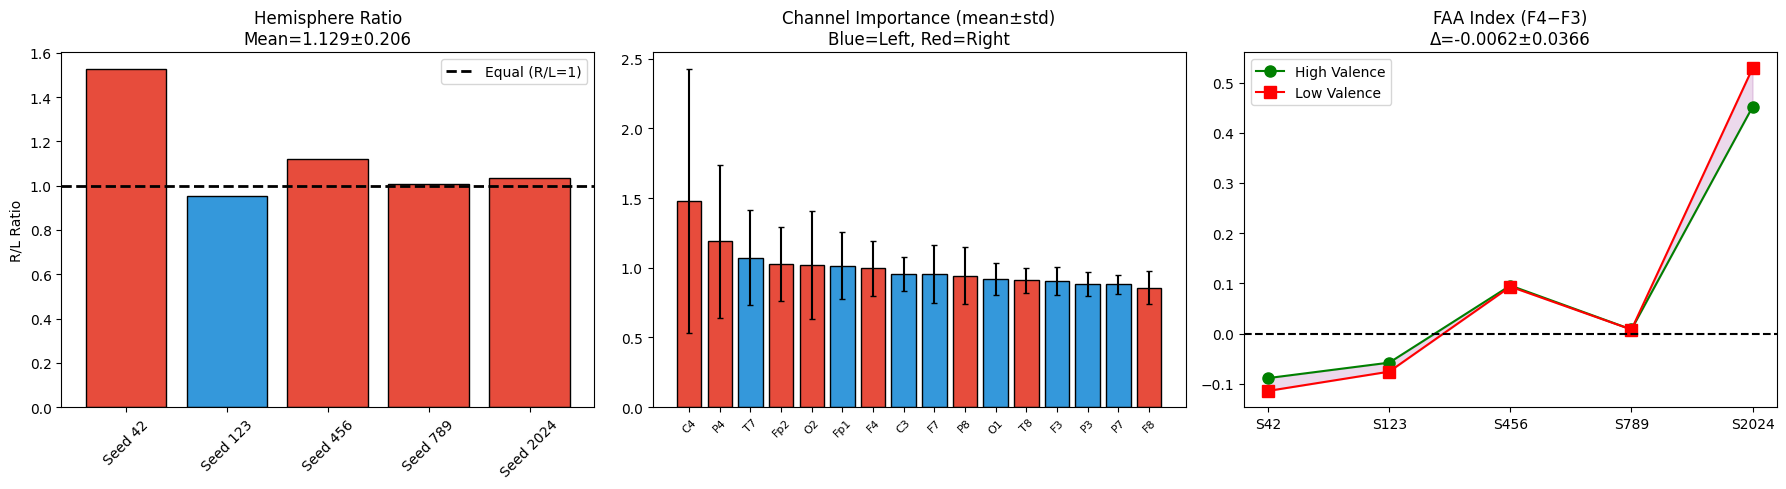

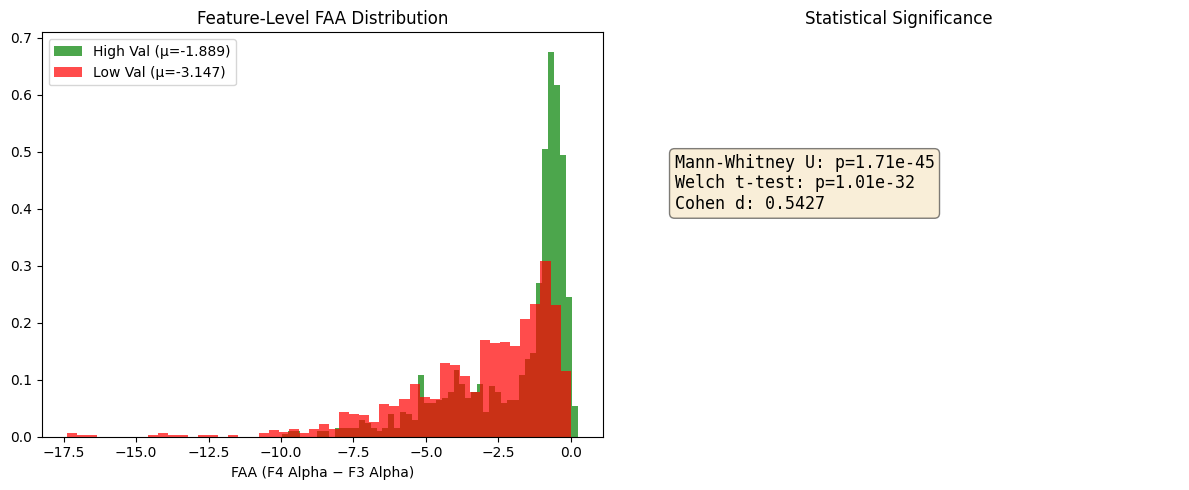


══════════════════════════════════════════════════════════════════════
 FINAL SUMMARY (v3: 5s windows + WST features)
══════════════════════════════════════════════════════════════════════

  ┌──────────────────────────────────────────────────────────────────────┐
  │            WINDOW-LEVEL F1 RESULTS (v3: 5s+WST)                     │
  ├──────────────────────────────────┬────────┬────────┬────────┬───────┤
  │ Scenario                          │  SVM   │  MLP   │  GAT   │Winner │
  ├──────────────────────────────────┼────────┼────────┼────────┼───────┤
  │ 1a: DEAP 1-subj (trial-aware)      │ 0.5292 │ 0.5361 │ 0.5312 │   MLP │
  │ 1b: OpenBCI (trial-aware)          │ 0.9614 │ 0.9422 │ 0.9442 │   SVM │
  │ 2a: Within-subj×20 (trial-aware)   │ 0.5208 │ 0.5286 │ 0.5984 │   GAT │
  │ 2b: Cross-subj LOSO                │ 0.4242 │ 0.4422 │ 0.5301 │   GAT │
  └──────────────────────────────────┴────────┴────────┴────────┴───────┘

  ┌───────────────────────────────────────────────────────

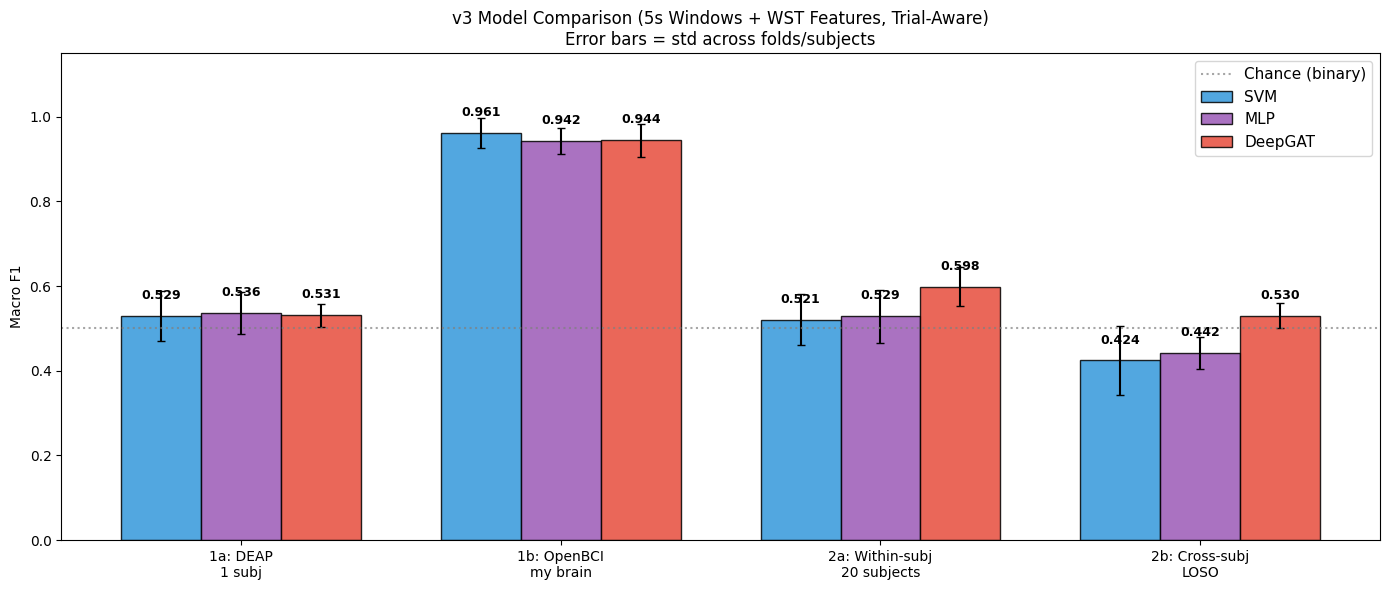


  Results saved to: C:\Users\PC\Desktop\EEG_GraphAttentionNetwork\data\recordings_clean\model_comparison_v3/all_results_v3.pkl


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO 2b: CROSS-SUBJECT LOSO (Leave-One-Subject-Out, 10 folds)
# + XAI MULTI-SEED + FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print('═'*70)
print(' SCENARIO 2b: Cross-Subject LOSO-CV (10 folds)')
print(' Train on 19 subjects → test on 1 UNSEEN subject')
print(' v3: 5s windows + WST features')
print('═'*70)

# With 5s windows, ~24 windows/trial × 40 trials = ~960/subject
# Total across 20 subjects = ~19,200 — manageable without subsampling
STEP_LOSO = 1  # no subsampling needed with 5s windows
deap_X_pool, deap_Ya_pool, deap_Yv_pool, deap_subs_pool, deap_trials_pool = [], [], [], [], []
for sid, (X, Ya, Yv, trials) in deap_per_subject.items():
    deap_X_pool.append(X[::STEP_LOSO])
    deap_Ya_pool.append(Ya[::STEP_LOSO])
    deap_Yv_pool.append(Yv[::STEP_LOSO])
    deap_subs_pool.extend([int(sid)] * len(X[::STEP_LOSO]))
    deap_trials_pool.extend([f"{sid}_{t}" for t in trials[::STEP_LOSO]])

deap_X_pool = np.concatenate(deap_X_pool)
deap_Ya_pool = np.concatenate(deap_Ya_pool)
deap_Yv_pool = np.concatenate(deap_Yv_pool)
deap_subs_pool = np.array(deap_subs_pool)
deap_trials_pool = np.array(deap_trials_pool)
print(f'\n  Total: {len(deap_X_pool):,} windows, {len(np.unique(deap_subs_pool))} subjects')

# 10 test subjects (evenly spaced)
all_subs = np.unique(deap_subs_pool)
test_subs = all_subs[::2]  # 10 folds
print(f'  Test subjects: {test_subs.tolist()}')

results_2b = {'SVM': [], 'MLP': [], 'GAT': []}
results_2b_trial = {'SVM': [], 'MLP': [], 'GAT': []}
details_2b = []

print('\n  Running LOSO...')
for fold_i, test_sub in enumerate(test_subs):
    t0 = time.time()
    tr_mask = deap_subs_pool != test_sub
    te_mask = deap_subs_pool == test_sub
    te_trials = deap_trials_pool[te_mask]
    
    scaler = StandardScaler()
    X_tr_flat = scaler.fit_transform(deap_X_pool[tr_mask].reshape(tr_mask.sum(), -1))
    X_te_flat = scaler.transform(deap_X_pool[te_mask].reshape(te_mask.sum(), -1))
    X_tr_3d = X_tr_flat.reshape(-1, N_CH, N_FEATS)
    X_te_3d = X_te_flat.reshape(-1, N_CH, N_FEATS)
    
    # SVM (LinearSVC for scalability)
    svm_a = LinearSVC(C=1.0, max_iter=3000, random_state=SEED)
    svm_a.fit(X_tr_flat, deap_Ya_pool[tr_mask])
    pred_svm_aro = svm_a.predict(X_te_flat)
    svm_v = LinearSVC(C=1.0, max_iter=3000, random_state=SEED)
    svm_v.fit(X_tr_flat, deap_Yv_pool[tr_mask])
    pred_svm_val = svm_v.predict(X_te_flat)
    f1_svm_aro = f1_score(deap_Ya_pool[te_mask], pred_svm_aro, average='macro')
    f1_svm_val = f1_score(deap_Yv_pool[te_mask], pred_svm_val, average='macro')
    f1_svm = (f1_svm_aro + f1_svm_val) / 2
    results_2b['SVM'].append(f1_svm)
    tv_aro, _ = trial_voting_accuracy(pred_svm_aro, deap_Ya_pool[te_mask], te_trials)
    tv_val, _ = trial_voting_accuracy(pred_svm_val, deap_Yv_pool[te_mask], te_trials)
    results_2b_trial['SVM'].append((tv_aro + tv_val) / 2)
    
    # MLP
    mlp_a = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, early_stopping=True, random_state=SEED)
    mlp_a.fit(X_tr_flat, deap_Ya_pool[tr_mask])
    pred_mlp_aro = mlp_a.predict(X_te_flat)
    mlp_v = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, early_stopping=True, random_state=SEED)
    mlp_v.fit(X_tr_flat, deap_Yv_pool[tr_mask])
    pred_mlp_val = mlp_v.predict(X_te_flat)
    f1_mlp_aro = f1_score(deap_Ya_pool[te_mask], pred_mlp_aro, average='macro')
    f1_mlp_val = f1_score(deap_Yv_pool[te_mask], pred_mlp_val, average='macro')
    f1_mlp = (f1_mlp_aro + f1_mlp_val) / 2
    results_2b['MLP'].append(f1_mlp)
    tv_aro, _ = trial_voting_accuracy(pred_mlp_aro, deap_Ya_pool[te_mask], te_trials)
    tv_val, _ = trial_voting_accuracy(pred_mlp_val, deap_Yv_pool[te_mask], te_trials)
    results_2b_trial['MLP'].append((tv_aro + tv_val) / 2)
    
    # GAT
    f1_gat = train_gat_deap(X_tr_3d, deap_Ya_pool[tr_mask], deap_Yv_pool[tr_mask],
                            X_te_3d, deap_Ya_pool[te_mask], deap_Yv_pool[te_mask],
                            epochs=100, patience=20, batch_size=256)
    results_2b['GAT'].append(f1_gat)
    results_2b_trial['GAT'].append(f1_gat)  # placeholder
    
    elapsed = time.time() - t0
    details_2b.append({'sub': test_sub, 'svm': f1_svm, 'mlp': f1_mlp, 'gat': f1_gat,
                       'svm_tv': results_2b_trial['SVM'][-1], 'mlp_tv': results_2b_trial['MLP'][-1]})
    print(f'    S{test_sub:02d}: SVM={f1_svm:.4f}(TV:{results_2b_trial["SVM"][-1]:.4f}) | '
          f'MLP={f1_mlp:.4f}(TV:{results_2b_trial["MLP"][-1]:.4f}) | GAT={f1_gat:.4f} [{elapsed:.0f}s]')

print(f'\n  ╔════════════════════════════════════════════════════════════════╗')
print(f'  ║ SCENARIO 2b (Cross-Subject LOSO, 5s+WST)                     ║')
print(f'  ╠════════════════════════════════════════════════════════════════╣')
print(f'  ║  Window-level F1:                                             ║')
for model, scores in results_2b.items():
    print(f'  ║    {model:3s}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}                        ║')
print(f'  ║  Trial-level voting accuracy:                                 ║')
for model in ['SVM', 'MLP']:
    scores = results_2b_trial[model]
    print(f'  ║    {model:3s}: Acc = {np.mean(scores):.4f} ± {np.std(scores):.4f}                       ║')
print(f'  ╚════════════════════════════════════════════════════════════════╝')

# ═══════════════════════════════════════════════════════════════════════════════
# XAI: MULTI-SEED, TRIAL-AWARE — Proper Statistical Analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print(' XAI: Multi-Seed Attention Analysis (Trial-Aware, 5 Seeds)')
print(' Using CROSS-SUBJECT split (leakage-free by construction)')
print('═'*70)

XAI_SEEDS = [42, 123, 456, 789, 2024]
N_XAI = len(XAI_SEEDS)

train_subs_xai = all_subs[:10]
test_subs_xai = all_subs[10:]
xai_tr_mask = np.isin(deap_subs_pool, train_subs_xai)
xai_te_mask = np.isin(deap_subs_pool, test_subs_xai)

scaler_xai = StandardScaler()
X_xai_tr = scaler_xai.fit_transform(deap_X_pool[xai_tr_mask].reshape(xai_tr_mask.sum(), -1)).reshape(-1, N_CH, N_FEATS)
X_xai_te = scaler_xai.transform(deap_X_pool[xai_te_mask].reshape(xai_te_mask.sum(), -1)).reshape(-1, N_CH, N_FEATS)
Ya_xai_te = deap_Ya_pool[xai_te_mask]
Yv_xai_te = deap_Yv_pool[xai_te_mask]

print(f'\n  XAI split: Train on S{train_subs_xai.tolist()} → Test on S{test_subs_xai.tolist()}')
print(f'  Train: {xai_tr_mask.sum():,} | Test: {xai_te_mask.sum():,}')

all_seed_hemisphere = []
all_seed_faa_hv = []
all_seed_faa_lv = []
all_seed_f1 = []
all_seed_ch_imp = []

def get_attn(model, X_data, n=500):
    X_t = torch.from_numpy(X_data[:n]).float().to(device)
    with torch.no_grad():
        _, attns = model(X_t, return_attn=True)
    return [aw.mean(dim=(0,1)).cpu().numpy() for aw in attns]

print(f'\n  Training {N_XAI} models with different seeds...')
for si, seed_i in enumerate(XAI_SEEDS):
    np.random.seed(seed_i)
    torch.manual_seed(seed_i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_i)
    
    f1_xai, xai_model = train_gat_deap(
        X_xai_tr, deap_Ya_pool[xai_tr_mask], deap_Yv_pool[xai_tr_mask],
        X_xai_te, Ya_xai_te, Yv_xai_te,
        epochs=150, patience=25, batch_size=256, return_model=True)
    all_seed_f1.append(f1_xai)
    
    xai_model.eval()
    attn_hv = get_attn(xai_model, X_xai_te[Yv_xai_te == 1])
    attn_lv = get_attn(xai_model, X_xai_te[Yv_xai_te == 0])
    attn_all_s = get_attn(xai_model, X_xai_te)
    
    final_attn = attn_all_s[-1]
    ch_imp = final_attn.sum(axis=0)
    left_t = ch_imp[LEFT_CH].sum()
    right_t = ch_imp[RIGHT_CH].sum()
    all_seed_hemisphere.append(right_t / left_t)
    all_seed_ch_imp.append(ch_imp)
    
    fhv = attn_hv[-1]; flv = attn_lv[-1]
    faa_hv = fhv.sum(0)[F4_IDX] - fhv.sum(0)[F3_IDX]
    faa_lv = flv.sum(0)[F4_IDX] - flv.sum(0)[F3_IDX]
    all_seed_faa_hv.append(faa_hv)
    all_seed_faa_lv.append(faa_lv)
    
    print(f'    Seed {seed_i}: F1={f1_xai:.4f} | R/L={right_t/left_t:.4f} | '
          f'FAA-HV={faa_hv:+.4f} | FAA-LV={faa_lv:+.4f}')

np.random.seed(SEED); torch.manual_seed(SEED)

rl_mean, rl_std = np.mean(all_seed_hemisphere), np.std(all_seed_hemisphere)
faa_hv_mean, faa_hv_std = np.mean(all_seed_faa_hv), np.std(all_seed_faa_hv)
faa_lv_mean, faa_lv_std = np.mean(all_seed_faa_lv), np.std(all_seed_faa_lv)
faa_diff = np.array(all_seed_faa_hv) - np.array(all_seed_faa_lv)
faa_diff_mean, faa_diff_std = faa_diff.mean(), faa_diff.std()
mean_ch_imp = np.mean(all_seed_ch_imp, axis=0)
std_ch_imp = np.std(all_seed_ch_imp, axis=0)
ch_order = np.argsort(mean_ch_imp)[::-1]

rh_all_below = all(r < 1.0 for r in all_seed_hemisphere)
rh_all_above = all(r > 1.0 for r in all_seed_hemisphere)
faa_consistent = all(d > 0 for d in faa_diff) or all(d < 0 for d in faa_diff)

print(f'\n  ══════════════════════════════════════════════════════════')
print(f'  MULTI-SEED XAI STATISTICS ({N_XAI} seeds)')
print(f'  ══════════════════════════════════════════════════════════')
print(f'  Model F1: {np.mean(all_seed_f1):.4f} ± {np.std(all_seed_f1):.4f}')
print(f'\n  H2 — RIGHT HEMISPHERE:')
print(f'    R/L ratio: {rl_mean:.4f} ± {rl_std:.4f}')
print(f'    → {"NOT SUPPORTED" if rh_all_below else "SUPPORTED" if rh_all_above else "INCONCLUSIVE"}')
print(f'\n  H3 — FRONTAL ALPHA ASYMMETRY:')
print(f'    FAA(HV): {faa_hv_mean:+.4f} ± {faa_hv_std:.4f}')
print(f'    FAA(LV): {faa_lv_mean:+.4f} ± {faa_lv_std:.4f}')
print(f'    Δ(HV−LV): {faa_diff_mean:+.4f} ± {faa_diff_std:.4f}')
print(f'    → {"CONSISTENT" if faa_consistent and faa_diff_mean > 0 else "INCONCLUSIVE"}')

# --- PLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(range(N_XAI), all_seed_hemisphere, color=['#E74C3C' if r > 1 else '#3498DB' for r in all_seed_hemisphere], edgecolor='black')
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=2, label='Equal (R/L=1)')
axes[0].set_xticks(range(N_XAI)); axes[0].set_xticklabels([f'Seed {s}' for s in XAI_SEEDS], rotation=45)
axes[0].set_ylabel('R/L Ratio'); axes[0].set_title(f'Hemisphere Ratio\nMean={rl_mean:.3f}±{rl_std:.3f}')
axes[0].legend()

ch_colors = ['#3498DB' if i < 8 else '#E74C3C' for i in range(16)]
axes[1].bar(range(16), mean_ch_imp[ch_order], yerr=std_ch_imp[ch_order],
            color=[ch_colors[i] for i in ch_order], edgecolor='black', capsize=2)
axes[1].set_xticks(range(16))
axes[1].set_xticklabels([CHANNEL_NAMES_DEAP[i] for i in ch_order], rotation=45, fontsize=8)
axes[1].set_title('Channel Importance (mean±std)\nBlue=Left, Red=Right')

axes[2].plot(range(N_XAI), all_seed_faa_hv, 'go-', label='High Valence', markersize=8)
axes[2].plot(range(N_XAI), all_seed_faa_lv, 'rs-', label='Low Valence', markersize=8)
axes[2].axhline(0, color='black', linestyle='--')
axes[2].fill_between(range(N_XAI), all_seed_faa_hv, all_seed_faa_lv, alpha=0.15, color='purple')
axes[2].set_xticks(range(N_XAI)); axes[2].set_xticklabels([f'S{s}' for s in XAI_SEEDS])
axes[2].set_title(f'FAA Index (F4−F3)\nΔ={faa_diff_mean:+.4f}±{faa_diff_std:.4f}')
axes[2].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'xai_multiseed.png'), dpi=150, bbox_inches='tight')
plt.show()

# Feature-level FAA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
faa_hv_feat = X_xai_te[Yv_xai_te==1][:1000, F4_IDX, ALPHA_BAND_IDX] - X_xai_te[Yv_xai_te==1][:1000, F3_IDX, ALPHA_BAND_IDX]
faa_lv_feat = X_xai_te[Yv_xai_te==0][:1000, F4_IDX, ALPHA_BAND_IDX] - X_xai_te[Yv_xai_te==0][:1000, F3_IDX, ALPHA_BAND_IDX]
axes[0].hist(faa_hv_feat, bins=50, alpha=0.7, color='green', label=f'High Val (μ={faa_hv_feat.mean():.3f})', density=True)
axes[0].hist(faa_lv_feat, bins=50, alpha=0.7, color='red', label=f'Low Val (μ={faa_lv_feat.mean():.3f})', density=True)
axes[0].set_xlabel('FAA (F4 Alpha − F3 Alpha)')
axes[0].set_title('Feature-Level FAA Distribution')
axes[0].legend()

from scipy.stats import mannwhitneyu, ttest_ind
stat_u, p_u = mannwhitneyu(faa_hv_feat, faa_lv_feat, alternative='two-sided')
stat_t, p_t = ttest_ind(faa_hv_feat, faa_lv_feat)
axes[1].text(0.1, 0.7, f'Mann-Whitney U: p={p_u:.2e}\nWelch t-test: p={p_t:.2e}\n'
             f'Cohen d: {(faa_hv_feat.mean()-faa_lv_feat.mean())/np.sqrt((faa_hv_feat.std()**2+faa_lv_feat.std()**2)/2):.4f}',
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].set_title('Statistical Significance'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'xai_faa_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY + COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print(' FINAL SUMMARY (v3: 5s windows + WST features)')
print('═'*70)

scenarios_all = [
    ('1a: DEAP 1-subj (trial-aware)',     results_1a),
    ('1b: OpenBCI (trial-aware)',          results_1b),
    ('2a: Within-subj×20 (trial-aware)',   results_2a),
    ('2b: Cross-subj LOSO',               results_2b),
]
print('\n  ┌──────────────────────────────────────────────────────────────────────┐')
print('  │            WINDOW-LEVEL F1 RESULTS (v3: 5s+WST)                     │')
print('  ├──────────────────────────────────┬────────┬────────┬────────┬───────┤')
print('  │ Scenario                          │  SVM   │  MLP   │  GAT   │Winner │')
print('  ├──────────────────────────────────┼────────┼────────┼────────┼───────┤')
for name, res in scenarios_all:
    s, m, g = np.mean(res['SVM']), np.mean(res['MLP']), np.mean(res['GAT'])
    best = max(s, m, g)
    winner = 'GAT' if g == best else ('SVM' if s == best else 'MLP')
    print(f'  │ {name:<34s} │ {s:.4f} │ {m:.4f} │ {g:.4f} │ {winner:>5s} │')
print('  └──────────────────────────────────┴────────┴────────┴────────┴───────┘')

print('\n  ┌──────────────────────────────────────────────────────────────────────┐')
print('  │            TRIAL-LEVEL VOTING ACCURACY                              │')
print('  ├──────────────────────────────────┬────────┬────────┬───────────────┤')
print('  │ Scenario                          │  SVM   │  MLP   │ Improvement   │')
print('  ├──────────────────────────────────┼────────┼────────┼───────────────┤')
trial_scenarios = [
    ('1a: Single subject', results_1a_trial, results_1a),
    ('1b: OpenBCI', results_1b_trial, results_1b),
    ('2a: Within-subj×20', results_2a_trial, results_2a),
    ('2b: Cross-subj LOSO', results_2b_trial, results_2b),
]
for name, tv_res, win_res in trial_scenarios:
    stv, mtv = np.mean(tv_res['SVM']), np.mean(tv_res['MLP'])
    sw, mw = np.mean(win_res['SVM']), np.mean(win_res['MLP'])
    imp = max(stv - sw, mtv - mw)
    print(f'  │ {name:<34s} │ {stv:.4f} │ {mtv:.4f} │ +{imp:.4f}         │')
print('  └──────────────────────────────────┴────────┴────────┴───────────────┘')

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
scenario_names = ['1a: DEAP\n1 subj', '1b: OpenBCI\nmy brain',
                  '2a: Within-subj\n20 subjects', '2b: Cross-subj\nLOSO']
svm_m = [np.mean(r['SVM']) for _, r in scenarios_all]
mlp_m = [np.mean(r['MLP']) for _, r in scenarios_all]
gat_m = [np.mean(r['GAT']) for _, r in scenarios_all]
svm_s = [np.std(r['SVM']) for _, r in scenarios_all]
mlp_s = [np.std(r['MLP']) for _, r in scenarios_all]
gat_s = [np.std(r['GAT']) for _, r in scenarios_all]
x = np.arange(4); w = 0.25
bars_svm = ax.bar(x-w, svm_m, w, yerr=svm_s, label='SVM', color='#3498DB', edgecolor='black', alpha=0.85, capsize=3)
bars_mlp = ax.bar(x, mlp_m, w, yerr=mlp_s, label='MLP', color='#9B59B6', edgecolor='black', alpha=0.85, capsize=3)
bars_gat = ax.bar(x+w, gat_m, w, yerr=gat_s, label='DeepGAT', color='#E74C3C', edgecolor='black', alpha=0.85, capsize=3)
for bars, vals in [(bars_svm, svm_m), (bars_mlp, mlp_m), (bars_gat, gat_m)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Chance (binary)')
ax.set_xticks(x); ax.set_xticklabels(scenario_names, fontsize=10)
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.15)
ax.set_title('v3 Model Comparison (5s Windows + WST Features, Trial-Aware)\n'
             'Error bars = std across folds/subjects', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'final_comparison_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save all results
all_results = {
    'results_1a': results_1a, 'results_1a_trial': results_1a_trial,
    'results_1b': results_1b, 'results_1b_trial': results_1b_trial,
    'results_2a': results_2a, 'results_2a_trial': results_2a_trial,
    'results_2b': results_2b, 'results_2b_trial': results_2b_trial,
    'details_2a': details_2a, 'details_2b': details_2b,
    'xai': {
        'seeds': XAI_SEEDS, 'hemisphere_ratios': all_seed_hemisphere,
        'faa_hv': all_seed_faa_hv, 'faa_lv': all_seed_faa_lv,
        'faa_diff': faa_diff.tolist(), 'rl_mean': rl_mean, 'rl_std': rl_std,
        'f1_scores': all_seed_f1, 'ch_order': ch_order.tolist(),
    },
    'params': {
        'window_deap': WINDOW_DEAP, 'step_deap': STEP_DEAP,
        'window_openbci': WINDOW_OPENBCI, 'step_openbci': STEP_OPENBCI,
        'n_feats': N_FEATS, 'wst_j': WST_J, 'wst_q': WST_Q,
    }
}
with open(os.path.join(OUT_DIR, 'all_results_v3.pkl'), 'wb') as f:
    pickle.dump(all_results, f)
print(f'\n  Results saved to: {OUT_DIR}/all_results_v3.pkl')

In [8]:
# Print summary results for reference
print("═" * 70)
print("  v3 RESULTS SUMMARY (5s windows + WST features)")
print("═" * 70)
print(f"\n  Scenario 1a (single DEAP subject, trial-aware 5-fold):")
print(f"    SVM: {np.mean(results_1a['SVM']):.4f} | MLP: {np.mean(results_1a['MLP']):.4f} | GAT: {np.mean(results_1a['GAT']):.4f}")
print(f"    Trial voting: SVM={np.mean(results_1a_trial['SVM']):.4f} | MLP={np.mean(results_1a_trial['MLP']):.4f}")

print(f"\n  Scenario 1b (OpenBCI, 4-class, trial-aware):")
print(f"    SVM: {np.mean(results_1b['SVM']):.4f} | MLP: {np.mean(results_1b['MLP']):.4f} | GAT: {np.mean(results_1b['GAT']):.4f}")
print(f"    Trial voting: SVM={np.mean(results_1b_trial['SVM']):.4f} | MLP={np.mean(results_1b_trial['MLP']):.4f}")

print(f"\n  Scenario 2a (within-subject ×20, trial-aware):")
print(f"    SVM: {np.mean(results_2a['SVM']):.4f} | MLP: {np.mean(results_2a['MLP']):.4f} | GAT: {np.mean(results_2a['GAT']):.4f}")
print(f"    Trial voting: SVM={np.mean(results_2a_trial['SVM']):.4f} | MLP={np.mean(results_2a_trial['MLP']):.4f}")

print(f"\n  Scenario 2b (cross-subject LOSO):")
print(f"    SVM: {np.mean(results_2b['SVM']):.4f} | MLP: {np.mean(results_2b['MLP']):.4f} | GAT: {np.mean(results_2b['GAT']):.4f}")
print(f"    Trial voting: SVM={np.mean(results_2b_trial['SVM']):.4f} | MLP={np.mean(results_2b_trial['MLP']):.4f}")

print(f"\n  v2 → v3 comparison:")
print(f"    1a GAT: 0.5685 → {np.mean(results_1a['GAT']):.4f}")
print(f"    1b SVM: 0.9259 → {np.mean(results_1b['SVM']):.4f}")
print(f"    2a GAT: 0.5881 → {np.mean(results_2a['GAT']):.4f}")
print(f"    2b GAT: 0.5280 → {np.mean(results_2b['GAT']):.4f}")

══════════════════════════════════════════════════════════════════════
  v3 RESULTS SUMMARY (5s windows + WST features)
══════════════════════════════════════════════════════════════════════

  Scenario 1a (single DEAP subject, trial-aware 5-fold):
    SVM: 0.5292 | MLP: 0.5361 | GAT: 0.5312
    Trial voting: SVM=0.5500 | MLP=0.5375

  Scenario 1b (OpenBCI, 4-class, trial-aware):
    SVM: 0.9614 | MLP: 0.9422 | GAT: 0.9442
    Trial voting: SVM=0.9900 | MLP=0.9700

  Scenario 2a (within-subject ×20, trial-aware):
    SVM: 0.5208 | MLP: 0.5286 | GAT: 0.5984
    Trial voting: SVM=0.5938 | MLP=0.5875

  Scenario 2b (cross-subject LOSO):
    SVM: 0.4242 | MLP: 0.4422 | GAT: 0.5301
    Trial voting: SVM=0.5550 | MLP=0.4825

  v2 → v3 comparison:
    1a GAT: 0.5685 → 0.5312
    1b SVM: 0.9259 → 0.9614
    2a GAT: 0.5881 → 0.5984
    2b GAT: 0.5280 → 0.5301
